Config Summary:
  POINTS        = 10000  (polygon shape resolution)
  ch            = 200  (spatial chunks / terrain detail)
  MONTE_CARLO_N = 5  (elevation draws per chunk)
  Total API calls expected: 1000

Loading local boundaries...

--- STEP 1: PROVINCES ---
Available: 1, 2, 3 (Bagmati), 4 (Gandaki), 5, 6 (Karnali), 7 (Sudur Pashchim)


Select Province Number (1-7):  3



--- STEP 2: DISTRICTS IN Bagmati ---
  1. BHAKTAPUR
  2. CHITAWAN
  3. DHADING
  4. DOLAKHA
  5. KABHREPALANCHOK
  6. KATHMANDU
  7. LALITPUR
  8. MAKAWANPUR
  9. NUWAKOT
  10. RAMECHHAP
  11. RASUWA
  12. SINDHULI
  13. SINDHUPALCHOK


Select District Number:  2



--- STEP 3: MUNICIPALITIES IN CHITAWAN ---
  1. Bharatpur
  2. Chitawan National Park
  3. Ichchhyakamana
  4. Kalika
  5. Khairahani
  6. Madi
  7. Rapti
  8. Ratnanagar


Select Municipality Number:  7



Generating 10000 sample points inside Rapti...
  10000 valid points generated inside polygon.
  Clustering into 200 spatial chunks via K-Means...
  Average points per chunk: 50.0

Running Monte Carlo elevation sampling...
  200 chunks × 5 draws = 1000 total API points

  Chunk    1/200 (36 pts in cluster)...     Fetching elevation for 5 points...
→ 228 m
  Chunk    2/200 (55 pts in cluster)...     Fetching elevation for 5 points...
→ 700 m
  Chunk    3/200 (47 pts in cluster)...     Fetching elevation for 5 points...
→ 240 m
  Chunk    4/200 (50 pts in cluster)...     Fetching elevation for 5 points...
→ 536 m
  Chunk    5/200 (66 pts in cluster)...     Fetching elevation for 5 points...
→ 1032 m
  Chunk    6/200 (37 pts in cluster)...     Fetching elevation for 5 points...
→ 224 m
  Chunk    7/200 (49 pts in cluster)...     Fetching elevation for 5 points...
→ 1097 m
  Chunk    8/200 (62 pts in cluster)...     Fetching elevation for 5 points...
→ 615 m
  Chunk    9/200 (64 pts in clu

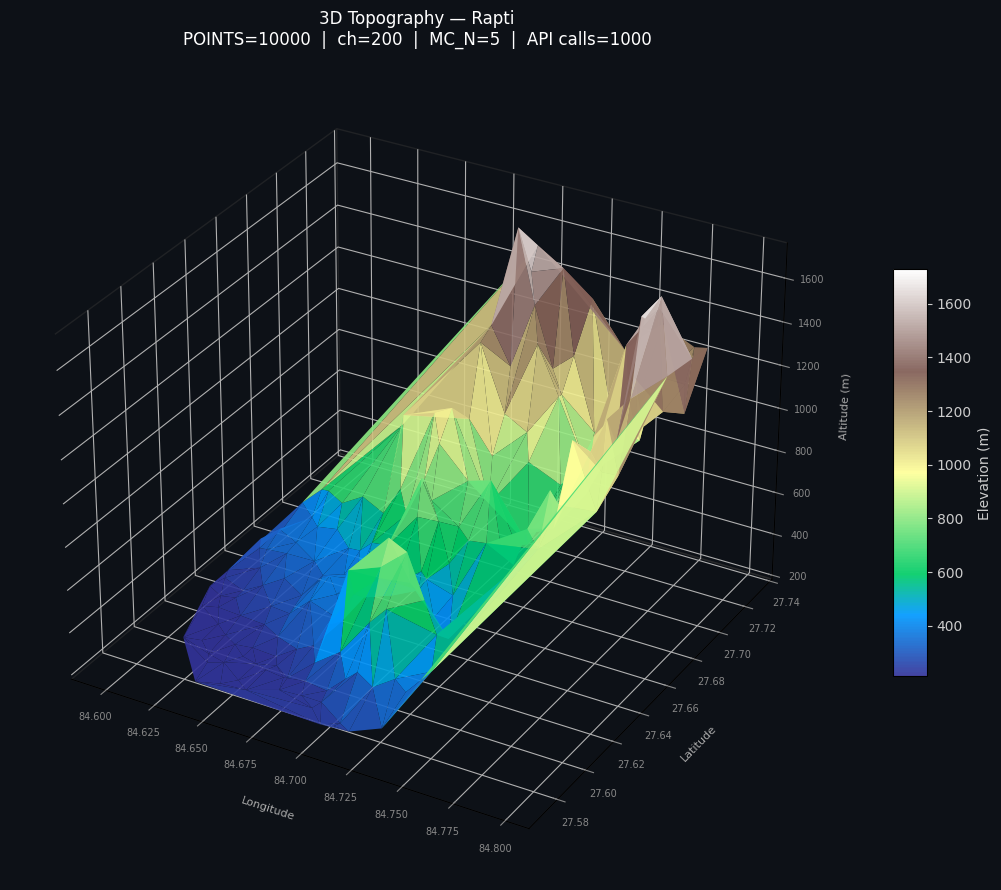


  Municipality  : Rapti
  District      : CHITAWAN
  Province      : Bagmati
  ─────────────────────────────────────────
  POINTS        : 10000
  Chunks (ch)   : 200
  MC draws/chunk: 5
  Total API calls: 1000
  ─────────────────────────────────────────
  Min elevation : 212 m
  Max elevation : 1728 m
  Mean elevation: 645 m
  Elev range    : 1516 m



In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.cluster import KMeans
from shapely.geometry import Point
import json
import requests
import random

# ==========================================
# CONFIGURATION — Tune these three knobs
# ==========================================
FILE_PATH     = 'localboundries.json'

POINTS        = 10000  # Random points for polygon shape sampling
                      # Rule: always keep POINTS >= ch * 20

ch            = 200   # Spatial chunks = number of elevation readings
                      # More = finer terrain mesh but more API calls

MONTE_CARLO_N = 5     # Elevation draws per chunk
                      # More = accurate elevation, diminishing returns after ~10
                      # Total API calls = ch * MONTE_CARLO_N

# ==========================================
# PROVINCE MAP
# ==========================================
PROVINCE_MAP = {
    "1": "1",
    "2": "2",
    "3": "Bagmati",
    "4": "Gandaki",
    "5": "5",
    "6": "Karnali",
    "7": "Sudur Pashchim"
}


# ==========================================
# ELEVATION FETCHING
# ==========================================
def get_real_altitudes(coords):
    """
    Fetches real elevation data from Open-Elevation API.
    coords: list of (lon, lat) tuples
    Returns: list of elevations in meters, or None on failure.
    """
    url = "https://api.open-elevation.com/api/v1/lookup"
    locations = [{"latitude": lat, "longitude": lon} for lon, lat in coords]
    payload = {"locations": locations}

    try:
        print(f"    Fetching elevation for {len(coords)} points...")
        response = requests.post(url, json=payload, timeout=60)
        if response.status_code == 200:
            return [res['elevation'] for res in response.json()['results']]
        else:
            print(f"    API Error {response.status_code}. Using fallback.")
            return None
    except Exception as e:
        print(f"    Connection failed: {e}. Using fallback.")
        return None


def fallback_elevation(lon, lat):
    """Rough elevation simulation based on Nepal's north-south gradient."""
    return 1000 + (lat - 27) * 45000 + random.uniform(-200, 200)


# ==========================================
# MONTE CARLO ELEVATION ESTIMATOR
# ==========================================
def monte_carlo_elevation(chunk_points, N=5):
    """
    For a single chunk (list of [lon, lat] points):
      - Randomly sample N points from within the chunk
      - Fetch their real elevations in one batched API call
      - Return the mean elevation and the coordinate of the
        pick closest to that mean (always a real inside-polygon point)
    """
    picks = random.choices(chunk_points, k=N)

    elevations = get_real_altitudes(picks)

    if elevations is None:
        elevations = [fallback_elevation(p[0], p[1]) for p in picks]

    mean_elev = float(np.mean(elevations))

    diffs = [abs(e - mean_elev) for e in elevations]
    best_pick = picks[int(np.argmin(diffs))]

    return best_pick[0], best_pick[1], mean_elev  # lon, lat, avg_elevation


# ==========================================
# VALIDATION
# ==========================================
def validate_config():
    """Warn the user if configuration values are likely to cause bad results."""
    issues = []

    if POINTS < ch * 20:
        issues.append(
            f"  WARNING: POINTS ({POINTS}) is less than ch*20 ({ch*20}).\n"
            f"           K-Means needs more points per cluster. "
            f"Recommend POINTS >= {ch * 20}."
        )

    if ch < 10:
        issues.append(
            f"  WARNING: ch={ch} is very low. "
            f"The terrain surface will be extremely coarse."
        )

    total_api_calls = ch * MONTE_CARLO_N
    if total_api_calls > 1000:
        issues.append(
            f"  WARNING: Total API calls = ch × MONTE_CARLO_N = {total_api_calls}. "
            f"This may hit Open-Elevation rate limits or timeout. "
            f"Consider reducing ch or MONTE_CARLO_N."
        )

    if MONTE_CARLO_N > 10:
        issues.append(
            f"  NOTE: MONTE_CARLO_N={MONTE_CARLO_N} is high. "
            f"Accuracy gains are minimal above 10 (diminishing returns)."
        )

    if issues:
        print("\n--- CONFIGURATION WARNINGS ---")
        for issue in issues:
            print(issue)
        print()


# ==========================================
# MAIN
# ==========================================
def main():

    # ---- 0. VALIDATE CONFIG ----
    validate_config()
    total_api_calls = ch * MONTE_CARLO_N
    print(f"Config Summary:")
    print(f"  POINTS        = {POINTS}  (polygon shape resolution)")
    print(f"  ch            = {ch}  (spatial chunks / terrain detail)")
    print(f"  MONTE_CARLO_N = {MONTE_CARLO_N}  (elevation draws per chunk)")
    print(f"  Total API calls expected: {total_api_calls}\n")

    # ---- 1. LOAD GEODATA ----
    print("Loading local boundaries...")
    with open(FILE_PATH, 'r') as f:
        data = json.load(f)
    gdf = gpd.GeoDataFrame.from_features(data['features'])

    # ---- 2. HIERARCHICAL SELECTION ----
    print("\n--- STEP 1: PROVINCES ---")
    print("Available: 1, 2, 3 (Bagmati), 4 (Gandaki), 5, 6 (Karnali), 7 (Sudur Pashchim)")
    p_num = input("Select Province Number (1-7): ").strip()
    if p_num not in PROVINCE_MAP:
        print("Invalid selection."); return
    p_name = PROVINCE_MAP[p_num]
    prov_gdf = gdf[gdf['Province'] == p_name]

    print(f"\n--- STEP 2: DISTRICTS IN {p_name} ---")
    districts = sorted(prov_gdf['DISTRICT'].unique())
    for i, d in enumerate(districts, 1):
        print(f"  {i}. {d}")
    d_idx = int(input("Select District Number: ")) - 1
    selected_dist = districts[d_idx]
    dist_gdf = prov_gdf[prov_gdf['DISTRICT'] == selected_dist]

    print(f"\n--- STEP 3: MUNICIPALITIES IN {selected_dist} ---")
    munis = sorted(dist_gdf['GaPa_NaPa'].unique())
    for i, m in enumerate(munis, 1):
        print(f"  {i}. {m}")
    m_idx = int(input("Select Municipality Number: ")) - 1
    selected_muni = munis[m_idx]
    muni_gdf = dist_gdf[dist_gdf['GaPa_NaPa'] == selected_muni]

    # ---- 3. GENERATE RANDOM POINTS INSIDE POLYGON ----
    print(f"\nGenerating {POINTS} sample points inside {selected_muni}...")
    poly = muni_gdf.geometry.iloc[0]
    minx, miny, maxx, maxy = poly.bounds

    points = []
    attempts = 0
    while len(points) < POINTS:
        p = Point(np.random.uniform(minx, maxx), np.random.uniform(miny, maxy))
        if poly.contains(p):
            points.append([p.x, p.y])
        attempts += 1
        if attempts > POINTS * 40:
            print(f"  Warning: Stopped early at {len(points)} points "
                  f"(polygon may be very irregular).")
            break

    print(f"  {len(points)} valid points generated inside polygon.")

    # Safety check — abort if not enough points for K-Means
    if len(points) < ch:
        print(f"  ERROR: Only {len(points)} points generated but ch={ch} clusters requested.")
        print(f"  Reduce ch or increase POINTS.")
        return

    # ---- 4. K-MEANS SPATIAL CHUNKING ----
    print(f"  Clustering into {ch} spatial chunks via K-Means...")
    kmeans = KMeans(n_clusters=ch, n_init=10, random_state=42)
    kmeans.fit(points)
    labels = kmeans.labels_

    # Group points by cluster
    chunks = {}
    for i, label in enumerate(labels):
        chunks.setdefault(label, []).append(points[i])

    avg_pts_per_chunk = len(points) / ch
    print(f"  Average points per chunk: {avg_pts_per_chunk:.1f}")

    # ---- 5. MONTE CARLO ELEVATION SAMPLING ----
    print(f"\nRunning Monte Carlo elevation sampling...")
    print(f"  {ch} chunks × {MONTE_CARLO_N} draws = {total_api_calls} total API points\n")

    results = []
    for cluster_id in range(ch):
        chunk_pts = chunks[cluster_id]
        print(f"  Chunk {cluster_id + 1:>4}/{ch} "
              f"({len(chunk_pts)} pts in cluster)...", end=" ")
        lon, lat, avg_elev = monte_carlo_elevation(chunk_pts, N=MONTE_CARLO_N)
        print(f"→ {avg_elev:.0f} m")
        results.append({
            'Chunk_ID':   cluster_id + 1,
            'Longitude':  lon,
            'Latitude':   lat,
            'Altitude_m': avg_elev,
            'MC_Draws':   MONTE_CARLO_N,
            'Cluster_Size': len(chunk_pts)
        })

    df = pd.DataFrame(results)

    # ---- 6. SAVE CSV ----
    csv_name = f"{selected_muni.replace(' ', '_')}_data.csv"
    df.to_csv(csv_name, index=False)
    print(f"\nData saved to: {csv_name}")

    # ---- 7. 3D TERRAIN VISUALIZATION ----
    print("Generating 3D terrain visualization...")

    fig = plt.figure(figsize=(14, 9), facecolor='#0d1117')
    ax = fig.add_subplot(111, projection='3d', facecolor='#0d1117')

    lons = df['Longitude'].values
    lats = df['Latitude'].values
    alts = df['Altitude_m'].values

    norm = mcolors.Normalize(vmin=alts.min(), vmax=alts.max())
    cmap = plt.cm.terrain

    # Clean triangulated surface — no scatter dots
    surf = ax.plot_trisurf(
        lons, lats, alts,
        cmap=cmap,
        norm=norm,
        edgecolor='none',
        alpha=0.92,
        linewidth=0
    )

    # Colorbar
    cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=12, pad=0.05)
    cbar.set_label('Elevation (m)', color='#cccccc', fontsize=10)
    cbar.ax.yaxis.set_tick_params(color='#cccccc')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#cccccc')

    # Title and labels
    ax.set_title(
        f"3D Topography — {selected_muni}\n"
        f"POINTS={POINTS}  |  ch={ch}  |  MC_N={MONTE_CARLO_N}  "
        f"|  API calls={total_api_calls}",
        color='white', fontsize=12, pad=15
    )
    ax.set_xlabel('Longitude', color='#aaaaaa', fontsize=8, labelpad=8)
    ax.set_ylabel('Latitude',  color='#aaaaaa', fontsize=8, labelpad=8)
    ax.set_zlabel('Altitude (m)', color='#aaaaaa', fontsize=8, labelpad=8)

    # Dark pane styling
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('#333333')
    ax.yaxis.pane.set_edgecolor('#333333')
    ax.zaxis.pane.set_edgecolor('#333333')
    ax.tick_params(colors='#888888', labelsize=7)
    ax.grid(True, color='#222222', linewidth=0.4)

    plt.tight_layout()

    img_name = f"{selected_muni.replace(' ', '_')}_3d_terrain.png"
    plt.savefig(img_name, dpi=150, bbox_inches='tight', facecolor='#0d1117')
    print(f"Map saved to: {img_name}")
    plt.show()

    # ---- 8. SUMMARY ----
    print(f"\n{'='*52}")
    print(f"  Municipality  : {selected_muni}")
    print(f"  District      : {selected_dist}")
    print(f"  Province      : {p_name}")
    print(f"  ─────────────────────────────────────────")
    print(f"  POINTS        : {POINTS}")
    print(f"  Chunks (ch)   : {ch}")
    print(f"  MC draws/chunk: {MONTE_CARLO_N}")
    print(f"  Total API calls: {total_api_calls}")
    print(f"  ─────────────────────────────────────────")
    print(f"  Min elevation : {alts.min():.0f} m")
    print(f"  Max elevation : {alts.max():.0f} m")
    print(f"  Mean elevation: {alts.mean():.0f} m")
    print(f"  Elev range    : {alts.max() - alts.min():.0f} m")
    print(f"{'='*52}\n")


if __name__ == "__main__":
    main()